In [23]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import numpy as np

def load_data(file_path):
    """Loads the ESG dataset from a CSV file."""
    try:
        df = pd.read_csv(file_path)
        print("Data loaded successfully.")
        return df
    except FileNotFoundError:
        print(f"Error: File not found at {file_path}")
        return None

def preprocess_data(df):
    """Preprocesses the data by handling missing values, selecting relevant columns, and encoding 'Region'."""

    # Select relevant columns for the rating pipeline
    relevant_cols = ['CompanyName', 'Industry', 'ESG_Environmental', 'ESG_Social', 'ESG_Governance', 'Year', 'Region']
    df = df[relevant_cols].copy()

    # Convert 'Region' column to string to ensure consistency
    df['Region'] = df['Region'].astype(str)

    # Convert ESG scores to numeric, coercing errors to NaN
    for col in ['ESG_Environmental', 'ESG_Social', 'ESG_Governance']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # Convert 'Year' to numeric, coercing errors to NaN
    df['Year'] = pd.to_numeric(df['Year'], errors='coerce')

    # Impute missing values in 'Industry' with the mode
    df['Industry'] = df['Industry'].fillna(df['Industry'].mode()[0])

    # Remove rows with NaN values in any of the relevant columns
    print(f"DataFrame shape before dropping NaNs: {df.shape}")
    df.dropna(subset=relevant_cols, inplace=True)
    print(f"DataFrame shape after dropping NaNs: {df.shape}")

    # Encode the Region column
    le = LabelEncoder()
    print(f"Unique values in 'Region' before encoding: {df['Region'].unique()}")
    df['Region'] = le.fit_transform(df['Region'])
    print("Regions encoded:", df['Region'].unique())

    print("Data preprocessing complete.")
    return df

def assign_esg_rating(row):
    """Assigns an ESG rating based on the average of E, S, and G scores."""
    avg_score = (row['ESG_Environmental'] + row['ESG_Social'] + row['ESG_Governance']) / 3

    if avg_score >= 75:
        return 'AAA'
    elif avg_score >= 60:
        return 'AA'
    elif avg_score >= 50:
        return 'A'
    elif avg_score >= 40:
        return 'BBB'
    elif avg_score >= 30:
        return 'BB'
    else:
        return 'CCC'

import pandas as pd

import pandas as pd

def main():
    """Main function to execute the ESG rating pipeline."""
    # 1. Load the data
    file_path = 'C:/Users/Admin/ESG_scorecard_project/data/company_esg_financial_dataset.csv'
    df = load_data(file_path)

    if df is None:
        return  # Exit if data loading failed

    # 2. Preprocess the data
    df = preprocess_data(df)

    # 3. Assign ESG ratings
    df['ESG_Rating'] = df.apply(assign_esg_rating, axis=1)

    # 4. Save the results
    df.to_csv('C:/Users/Admin/ESG_scorecard_project/data/processed_data.csv', index=False)
    print("ESG ratings assigned and saved to 'C:/Users/Admin/ESG_scorecard_project/data/processed_data.csv'")

if __name__ == "__main__":
    main()


Data loaded successfully.
DataFrame shape before dropping NaNs: (11000, 7)
DataFrame shape after dropping NaNs: (11000, 7)
Unique values in 'Region' before encoding: ['Latin America' 'Asia' 'Africa' 'Middle East' 'Oceania' 'Europe'
 'North America']
Regions encoded: [3 1 0 4 6 2 5]
Data preprocessing complete.
ESG ratings assigned and saved to 'C:/Users/Admin/ESG_scorecard_project/data/processed_data.csv'


In [25]:
import pandas as pd

df_processed = pd.read_csv('C:/Users/Admin/ESG_scorecard_project/data/processed_data.csv')
print(df_processed[['CompanyName', 'ESG_Environmental', 'ESG_Social', 'ESG_Governance', 'ESG_Rating']].head(10))


  CompanyName  ESG_Environmental  ESG_Social  ESG_Governance ESG_Rating
0   Company_1               60.7        33.5            76.8          A
1   Company_1               58.9        32.8            78.5          A
2   Company_1               57.6        34.0            77.8          A
3   Company_1               62.3        33.4            78.3          A
4   Company_1               63.7        30.0            76.1          A
5   Company_1               65.1        28.5            73.5          A
6   Company_1               66.8        25.5            74.6          A
7   Company_1               69.0        27.1            76.9          A
8   Company_1               68.3        27.0            78.1          A
9   Company_1               68.9        29.9            76.8          A


In [1]:
import pandas as pd

df = pd.read_csv('C:/Users/Admin/ESG_scorecard_project/data/processed_data.csv')

# Summary statistics for ESG pillars
print(df[['ESG_Environmental', 'ESG_Social', 'ESG_Governance']].describe())

# Count of companies per region
print(df['Region'].value_counts())

# Count of companies per industry
print(df['Industry'].value_counts().head(10))

# Count of companies per ESG rating
print(df['ESG_Rating'].value_counts())


       ESG_Environmental    ESG_Social  ESG_Governance
count       11000.000000  11000.000000    11000.000000
mean           56.416991     55.660582       51.767655
std            26.767233     23.356152       25.323370
min             0.000000      0.000000        0.000000
25%            34.700000     37.600000       30.775000
50%            55.600000     55.150000       52.100000
75%            79.000000     73.800000       73.000000
max           100.000000    100.000000      100.000000
Region
1    1672
6    1661
4    1617
2    1540
5    1540
3    1507
0    1463
Name: count, dtype: int64
Industry
Healthcare        1331
Transportation    1287
Manufacturing     1287
Consumer Goods    1276
Finance           1243
Energy            1188
Utilities         1177
Retail            1166
Technology        1045
Name: count, dtype: int64
ESG_Rating
AA     2999
A      2607
BBB    2248
BB     1178
AAA    1154
CCC     814
Name: count, dtype: int64


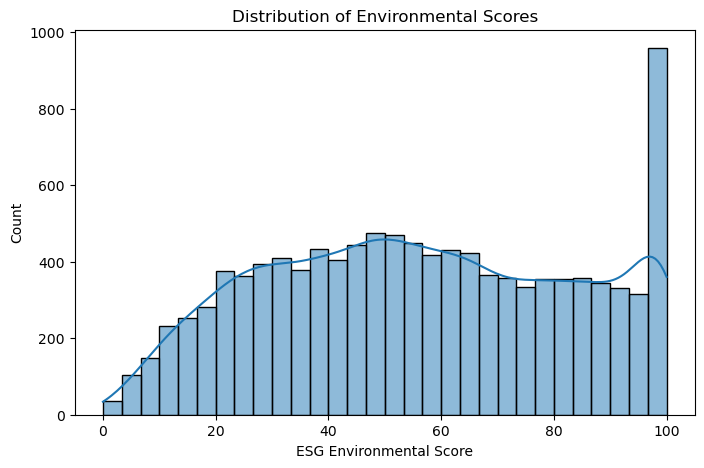

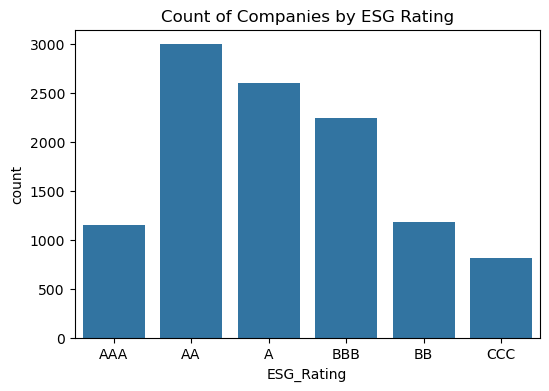

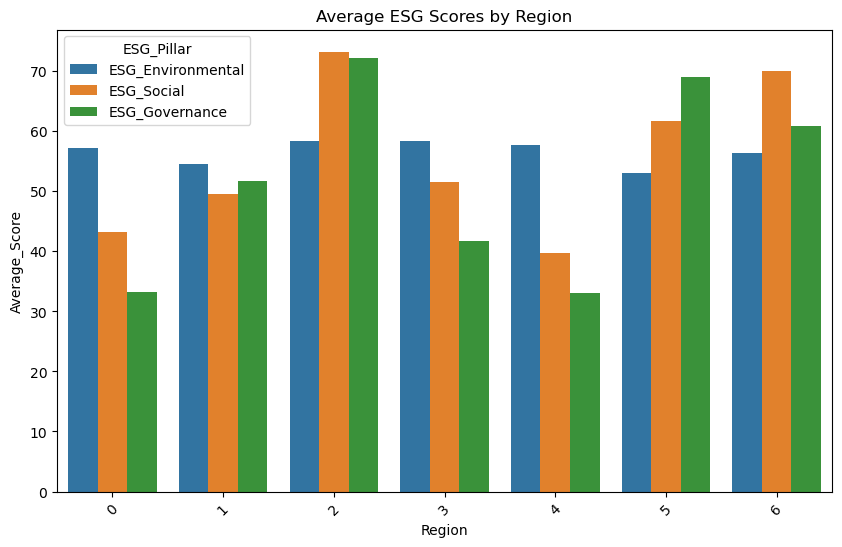

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of ESG Environmental scores
plt.figure(figsize=(8,5))
sns.histplot(df['ESG_Environmental'], bins=30, kde=True)
plt.title('Distribution of Environmental Scores')
plt.xlabel('ESG Environmental Score')
plt.ylabel('Count')
plt.show()

# ESG Ratings count plot
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='ESG_Rating', order=['AAA', 'AA', 'A', 'BBB', 'BB', 'CCC'])
plt.title('Count of Companies by ESG Rating')
plt.show()

# Average ESG scores by Region
plt.figure(figsize=(10,6))
region_avg = df.groupby('Region')[['ESG_Environmental', 'ESG_Social', 'ESG_Governance']].mean().reset_index()
region_avg_melted = region_avg.melt(id_vars='Region', var_name='ESG_Pillar', value_name='Average_Score')
sns.barplot(data=region_avg_melted, x='Region', y='Average_Score', hue='ESG_Pillar')
plt.title('Average ESG Scores by Region')
plt.xticks(rotation=45)
plt.show()
